# CW2 Option A: Fine-Tuning a Transformer for Fault Classification

This notebook loads pre-trained checkpoints produced by the training pipeline
(`option_a_main.py`, run via SLURM on NCC) and reproduces all evaluation
and visualisation. The training code is in the companion modules:
`option_a_data.py`, `option_a_model.py`, `option_a_train.py`,
`option_a_evaluate.py`, orchestrated by `option_a_main.py`.

**Dataset:** SMRT Maintenance Logs (10,785 entries, 6 functional fault categories)
**Model:** RoBERTa-base with custom classification head
**Technique:** Two-stage fine-tuning (frozen then unfrozen backbone) + LoRA comparison

In [1]:
# -- Imports and configuration ------------------------------------------
import os, json, warnings
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_recall_fscore_support)

OUTPUT_DIR = Path("output")
assert OUTPUT_DIR.exists(), "Run option_a_main.py first to generate output/ artifacts"

with open(OUTPUT_DIR / "config.json") as f:
    CFG = json.load(f)

with open(OUTPUT_DIR / "baselines.json") as f:
    baselines = json.load(f)

print(f"Config loaded: {CFG['NUM_CLASSES']} classes, model={CFG['MODEL_PRESET']}")

Config loaded: 6 classes, model=roberta_base_en


Loaded 10785 maintenance log entries
Original unique components: 766

Functional categories (6):
  Doors                  920 (8.5%)
  Electrical            1378 (12.8%)
  HVAC                  2276 (21.1%)
  Lighting              1284 (11.9%)
  Other                 4331 (40.2%)
  Propulsion             596 (5.5%)

Train: 8250, Val: 1456, Test: 1079


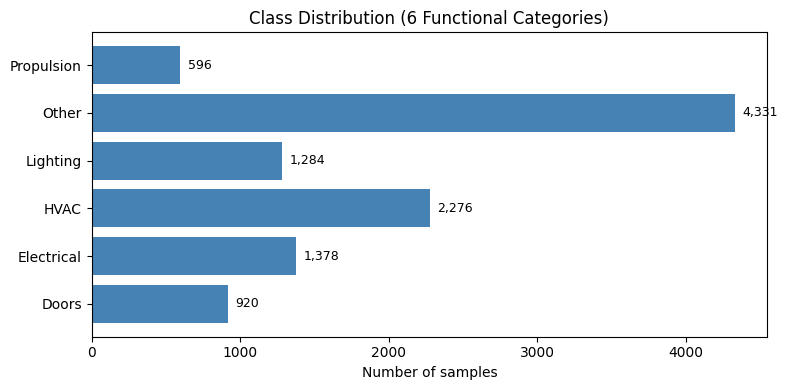

Total samples: 10,785
Test set: 1,079 samples


In [2]:
# -- Load dataset and apply functional grouping -------------------------
# Uses the same data pipeline as training (option_a_data.py).
from option_a_data import (CLASS_MAP, LABEL_ORDER, SEED,
                           load_and_prepare_data)

(X_train_raw, y_train, X_val_raw, y_val,
 X_test_raw, y_test, label_names) = load_and_prepare_data()

# Class distribution bar chart
import pandas as pd
df = pd.read_csv("data/smrt_maintenance_logs.csv")
texts_all = df["fault_text"].values
labels_raw = df["label_name"].values
splits = df["split"].values

train_mask = splits == "train"
label_counts = pd.Series(labels_raw[train_mask]).value_counts()
top_labels = set(label_counts[label_counts >= 50].index)
labels_grouped = np.array([
    CLASS_MAP[l] if (l in top_labels and l in CLASS_MAP) else "Other"
    for l in labels_raw
])

fig, ax = plt.subplots(figsize=(8, 4))
counts = [np.sum(labels_grouped == name) for name in label_names]
bars = ax.barh(label_names, counts, color="steelblue")
ax.set_xlabel("Number of samples")
ax.set_title("Class Distribution (6 Functional Categories)")
for bar, c in zip(bars, counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{c:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total samples: {len(df):,}")
print(f"Test set: {len(y_test):,} samples")

In [3]:
# -- Baseline results ---------------------------------------------------
print(f"Majority class baseline: {baselines['majority_acc']:.4f}")
print(f"TF-IDF + LogReg baseline: {baselines['tfidf_acc']:.4f}")
print(f"\nThe Transformer must beat {baselines['tfidf_acc']:.4f} to justify its complexity.")


Majority class baseline: 0.4226
TF-IDF + LogReg baseline: 0.7943

The Transformer must beat 0.7943 to justify its complexity.


## Training Curves

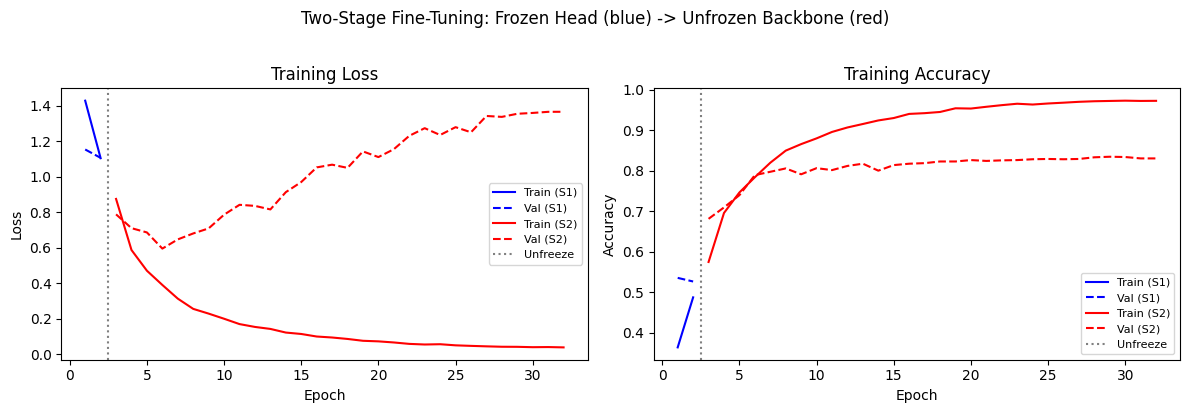

Stage 1 best val accuracy: 0.5357
Stage 2 best val accuracy: 0.8345
Improvement: +0.2988


In [4]:
# -- Training curves: Stage 1 + Stage 2 --------------------------------
with open(OUTPUT_DIR / "history_stage1.json") as f:
    h1 = json.load(f)
with open(OUTPUT_DIR / "history_stage2.json") as f:
    h2 = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
n1 = len(h1["loss"])
n2 = len(h2["loss"])
epochs_s1 = list(range(1, n1 + 1))
epochs_s2 = list(range(n1 + 1, n1 + n2 + 1))

# Loss
axes[0].plot(epochs_s1, h1["loss"], "b-", label="Train (S1)")
axes[0].plot(epochs_s1, h1["val_loss"], "b--", label="Val (S1)")
axes[0].plot(epochs_s2, h2["loss"], "r-", label="Train (S2)")
axes[0].plot(epochs_s2, h2["val_loss"], "r--", label="Val (S2)")
axes[0].axvline(n1 + 0.5, color="gray", linestyle=":", label="Unfreeze")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss"); axes[0].legend(fontsize=8)

# Accuracy
axes[1].plot(epochs_s1, h1["accuracy"], "b-", label="Train (S1)")
axes[1].plot(epochs_s1, h1["val_accuracy"], "b--", label="Val (S1)")
axes[1].plot(epochs_s2, h2["accuracy"], "r-", label="Train (S2)")
axes[1].plot(epochs_s2, h2["val_accuracy"], "r--", label="Val (S2)")
axes[1].axvline(n1 + 0.5, color="gray", linestyle=":", label="Unfreeze")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy"); axes[1].legend(fontsize=8)

plt.suptitle("Two-Stage Fine-Tuning: Frozen Head (blue) -> Unfrozen Backbone (red)", y=1.02)
plt.tight_layout()
plt.show()

print(f"Stage 1 best val accuracy: {CFG['s1_val_acc']:.4f}")
print(f"Stage 2 best val accuracy: {CFG['s2_val_acc']:.4f}")
print(f"Improvement: {CFG['s2_val_acc'] - CFG['s1_val_acc']:+.4f}")


## Test Set Evaluation

In [5]:
# -- Test set evaluation ------------------------------------------------
data = np.load(OUTPUT_DIR / "test_predictions.npz", allow_pickle=True)
y_test = data["y_test"]
y_pred = data["y_pred"]
y_pred_probs = data["y_pred_probs"]
label_names = list(data["label_names"])
X_test_raw = data["X_test_raw"]

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_names, digits=4))

test_acc = np.mean(y_pred == y_test)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")


Classification Report:

              precision    recall  f1-score   support

       Doors     0.7766    0.8022    0.7892        91
  Electrical     0.6809    0.7869    0.7300       122
        HVAC     0.7992    0.8233    0.8110       232
    Lighting     0.9023    0.9449    0.9231       127
       Other     0.8389    0.7654    0.8005       456
  Propulsion     0.8214    0.9020    0.8598        51

    accuracy                         0.8109      1079
   macro avg     0.8032    0.8374    0.8189      1079
weighted avg     0.8139    0.8109    0.8111      1079

Test accuracy: 0.8109
Macro F1:      0.8189
Weighted F1:   0.8111


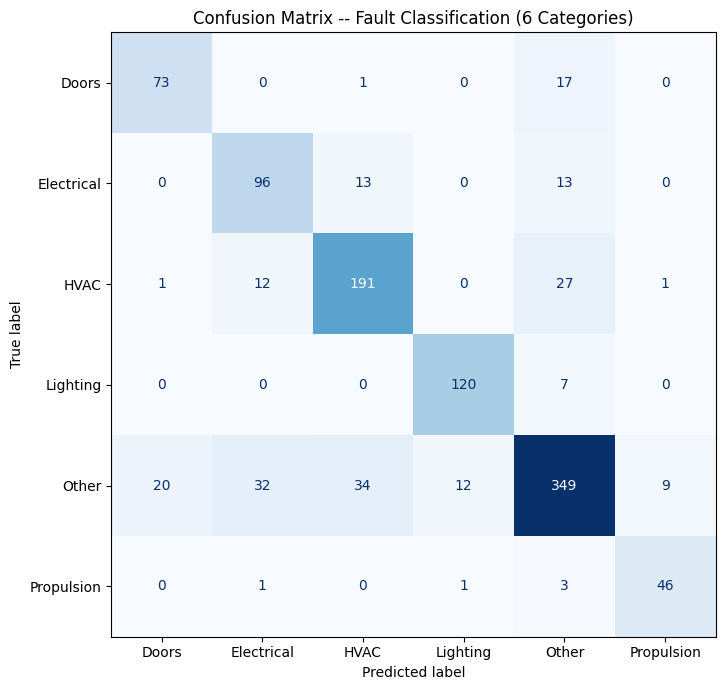

In [6]:
# -- Confusion matrix ---------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix -- Fault Classification (6 Categories)")
plt.tight_layout()
plt.show()


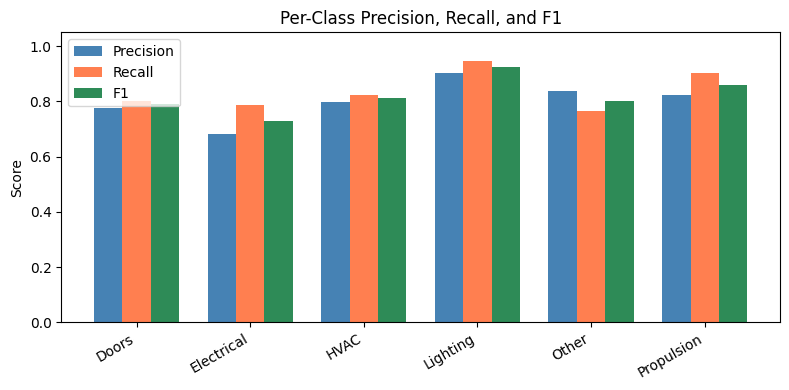

  Doors            P=0.777  R=0.802  F1=0.789  (n=91)
  Electrical       P=0.681  R=0.787  F1=0.730  (n=122)
  HVAC             P=0.799  R=0.823  F1=0.811  (n=232)
  Lighting         P=0.902  R=0.945  F1=0.923  (n=127)
  Other            P=0.839  R=0.765  F1=0.800  (n=456)
  Propulsion       P=0.821  R=0.902  F1=0.860  (n=51)


In [7]:
# -- Per-class metrics bar chart ----------------------------------------
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(label_names))
)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(label_names))
w = 0.25
ax.bar(x - w, precision, w, label="Precision", color="steelblue")
ax.bar(x, recall, w, label="Recall", color="coral")
ax.bar(x + w, f1, w, label="F1", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision, Recall, and F1")
ax.legend()
plt.tight_layout()
plt.show()

for i, name in enumerate(label_names):
    print(f"  {name:15s}  P={precision[i]:.3f}  R={recall[i]:.3f}  F1={f1[i]:.3f}  (n={support[i]})")


In [8]:
# -- Error analysis -----------------------------------------------------
misclassified = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified)}/{len(y_test)} ({100*len(misclassified)/len(y_test):.1f}%)")

print("\nSample misclassifications:")
rng = np.random.default_rng(42)
sample_idx = rng.choice(misclassified, size=min(8, len(misclassified)), replace=False)
for idx in sample_idx:
    true_label = label_names[y_test[idx]]
    pred_label = label_names[y_pred[idx]]
    text = str(X_test_raw[idx])[:100]
    print(f"  True: {true_label:15s}  Pred: {pred_label:15s}")
    print(f'  "{text}..."')


Total misclassified: 204/1079 (18.9%)

Sample misclassifications:
  True: Electrical       Pred: HVAC           
  "BCU fault at rear M1 car when train entering station since SBW2. Fault self cleared when train depar..."
  True: Other            Pred: Doors          
  "3604 A3 door not proven close. To check..."
  True: Other            Pred: Lighting       
  "3530 B5 saloon light not working...."
  True: HVAC             Pred: Other          
  "3543 brake fault train prep..."
  True: Doors            Pred: Other          
  "TC reported DIR lights up intermittentlyfor few seconds. No DMI indication on TIMS. TC reported DIR ..."
  True: Electrical       Pred: HVAC           
  "3512-BCU Fault During Train Prep.To Rect..."
  True: HVAC             Pred: Electrical     
  "DC reported 683/684 - BCU fault during t..."
  True: Electrical       Pred: HVAC           
  "3680 - FOUND BCU FAULT DURING DT CHECK..."


In [9]:
# -- Dual evaluation: overall vs fault-specific -------------------------
other_idx = label_names.index("Other") if "Other" in label_names else None

if other_idx is not None:
    fault_mask = y_test != other_idx
    y_test_faults = y_test[fault_mask]
    y_pred_faults = y_pred[fault_mask]

    fault_acc = np.mean(y_pred_faults == y_test_faults)
    fault_macro_f1 = f1_score(y_test_faults, y_pred_faults, average="macro")
    fault_weighted_f1 = f1_score(y_test_faults, y_pred_faults, average="weighted")

    print("=" * 55)
    print("DUAL EVALUATION: Overall vs Fault-Specific")
    print("=" * 55)
    print(f"{'Metric':<25s} {'All Classes':>12s} {'Faults Only':>12s}")
    print("-" * 49)
    print(f"{'Test samples':<25s} {len(y_test):>12d} {len(y_test_faults):>12d}")
    print(f"{'Accuracy':<25s} {test_acc:>12.4f} {fault_acc:>12.4f}")
    print(f"{'Macro F1':<25s} {macro_f1:>12.4f} {fault_macro_f1:>12.4f}")
    print(f"{'Weighted F1':<25s} {weighted_f1:>12.4f} {fault_weighted_f1:>12.4f}")


DUAL EVALUATION: Overall vs Fault-Specific
Metric                     All Classes  Faults Only
-------------------------------------------------
Test samples                      1079          623
Accuracy                        0.8109       0.8443
Macro F1                        0.8189       0.7494
Weighted F1                     0.8111       0.8917


## LoRA Fine-Tuning Comparison

LoRA model -- Trainable: 1,998,598 / 126,032,902 (1.59%)
LoRA test accuracy: 0.8026
LoRA macro F1:      0.8111

Full fine-tuning test accuracy: 0.8109
Difference: -0.0083


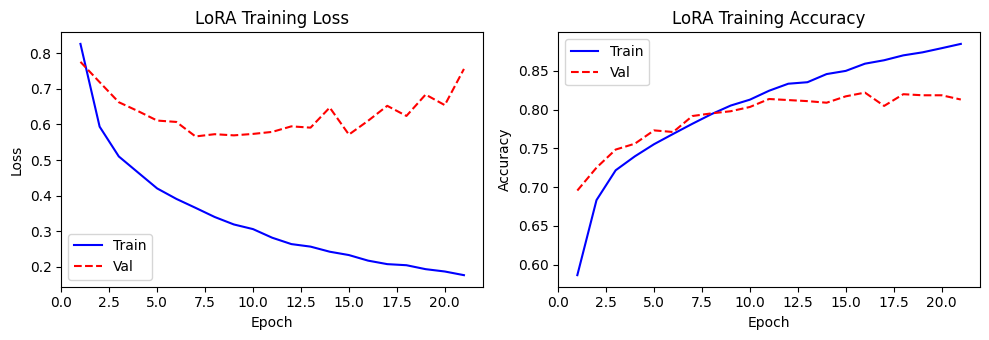

In [10]:
# -- LoRA evaluation ----------------------------------------------------
y_pred_lora = data["y_pred_lora"]
lora_acc = np.mean(y_pred_lora == y_test)
lora_f1 = f1_score(y_test, y_pred_lora, average="macro")

print(f"LoRA model -- Trainable: {CFG['lora_trainable']:,} / {CFG['lora_total']:,} "
      f"({100*CFG['lora_trainable']/CFG['lora_total']:.2f}%)")
print(f"LoRA test accuracy: {lora_acc:.4f}")
print(f"LoRA macro F1:      {lora_f1:.4f}")
print(f"\nFull fine-tuning test accuracy: {test_acc:.4f}")
print(f"Difference: {lora_acc - test_acc:+.4f}")

# LoRA training curves
with open(OUTPUT_DIR / "history_lora.json") as f:
    h_lora = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
epochs_lora = range(1, len(h_lora["loss"]) + 1)
axes[0].plot(epochs_lora, h_lora["loss"], "b-", label="Train")
axes[0].plot(epochs_lora, h_lora["val_loss"], "r--", label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("LoRA Training Loss"); axes[0].legend()

axes[1].plot(epochs_lora, h_lora["accuracy"], "b-", label="Train")
axes[1].plot(epochs_lora, h_lora["val_accuracy"], "r--", label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("LoRA Training Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()


## Summary

In [11]:
# -- Summary comparison table -------------------------------------------
print(f"{'Method':<35s} {'Val Acc':>10s} {'Test Acc':>10s} {'Macro F1':>10s}")
print("\u2500" * 65)
print(f"{'Majority class baseline':<35s} {'\u2014':>10s} {baselines['majority_acc']:>10.4f} {'\u2014':>10s}")
print(f"{'TF-IDF + LogReg baseline':<35s} {'\u2014':>10s} {baselines['tfidf_acc']:>10.4f} {'\u2014':>10s}")
print(f"{'Stage 1 (frozen backbone)':<35s} {CFG['s1_val_acc']:>10.4f} {'\u2014':>10s} {'\u2014':>10s}")
print(f"{'Stage 2 (partial fine-tuning)':<35s} {CFG['s2_val_acc']:>10.4f} {test_acc:>10.4f} {macro_f1:>10.4f}")
lora_label = f"LoRA (rank={CFG['LORA_RANK']})"
print(f"{lora_label:<35s} {'\u2014':>10s} {lora_acc:>10.4f} {lora_f1:>10.4f}")

if other_idx is not None:
    print()
    print("\u2500" * 65)
    print("Fault-specific evaluation (excluding 'Other'):")
    print(f"  RoBERTa fault accuracy:  {fault_acc:.4f}")
    print(f"  RoBERTa fault macro F1:  {fault_macro_f1:.4f}")

print()
print("Key findings:")
print(f"  1. Two-stage fine-tuning improves val acc by +{CFG['s2_val_acc'] - CFG['s1_val_acc']:.1%}")
print(f"  2. LoRA achieves {lora_acc:.1%} with {100*CFG['lora_trainable']/CFG['lora_total']:.1f}% trainable params")
print(f"  3. Domain transfer from general language to maintenance text is effective")


Method                                 Val Acc   Test Acc   Macro F1


─────────────────────────────────────────────────────────────────
Majority class baseline                      —     0.4226          —
TF-IDF + LogReg baseline                     —     0.7943          —
Stage 1 (frozen backbone)               0.5357          —          —
Stage 2 (partial fine-tuning)           0.8345     0.8109     0.8189
LoRA (rank=8)                                —     0.8026     0.8111

─────────────────────────────────────────────────────────────────
Fault-specific evaluation (excluding 'Other'):
  RoBERTa fault accuracy:  0.8443
  RoBERTa fault macro F1:  0.7494

Key findings:
  1. Two-stage fine-tuning improves val acc by +29.9%
  2. LoRA achieves 80.3% with 1.6% trainable params
  3. Domain transfer from general language to maintenance text is effective


## Summary and Limitations

Key results and limitations are discussed in the accompanying research report.
The trained model checkpoints, training histories, and evaluation artifacts
are saved in the `output/` directory for reproducibility.
